<a href="https://colab.research.google.com/github/ArjunBhakta/Data-Science-Cohort-20/blob/main/Project_4_Music_Popularity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available AWS at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



## Summary of Approach

## Data Loading

In [1]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: hPZ7Br/cFrlyqZdpHTIm7a/MVNDYS3gJpooIrtmrmPqiN9eOrva25m74uu4Di33x2g5XT4mfXH1yza6xIUtNxA/7DJalsLcM
x-amz-request-id: PZQYSJZHA9H37FS8
Date: Thu, 21 May 2026 15:52:29 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [2]:
!curl -s -O {url}

In [3]:
ls -la

total 740
drwxr-xr-x 1 root root   4096 May 21 15:50 ./
drwxr-xr-x 1 root root   4096 May 21 15:48 ../
drwxr-xr-x 4 root root   4096 May 18 13:26 .config/
drwxr-xr-x 1 root root   4096 May 18 13:26 sample_data/
-rw-r--r-- 1 root root 738124 May 21 15:52 Spotify.csv


In [4]:
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


In [5]:
import pandas as pd
import missingno as msno
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn import metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

In [6]:
df = pd.read_csv(url)

In [7]:
df.shape

(1556, 23)

<Axes: >

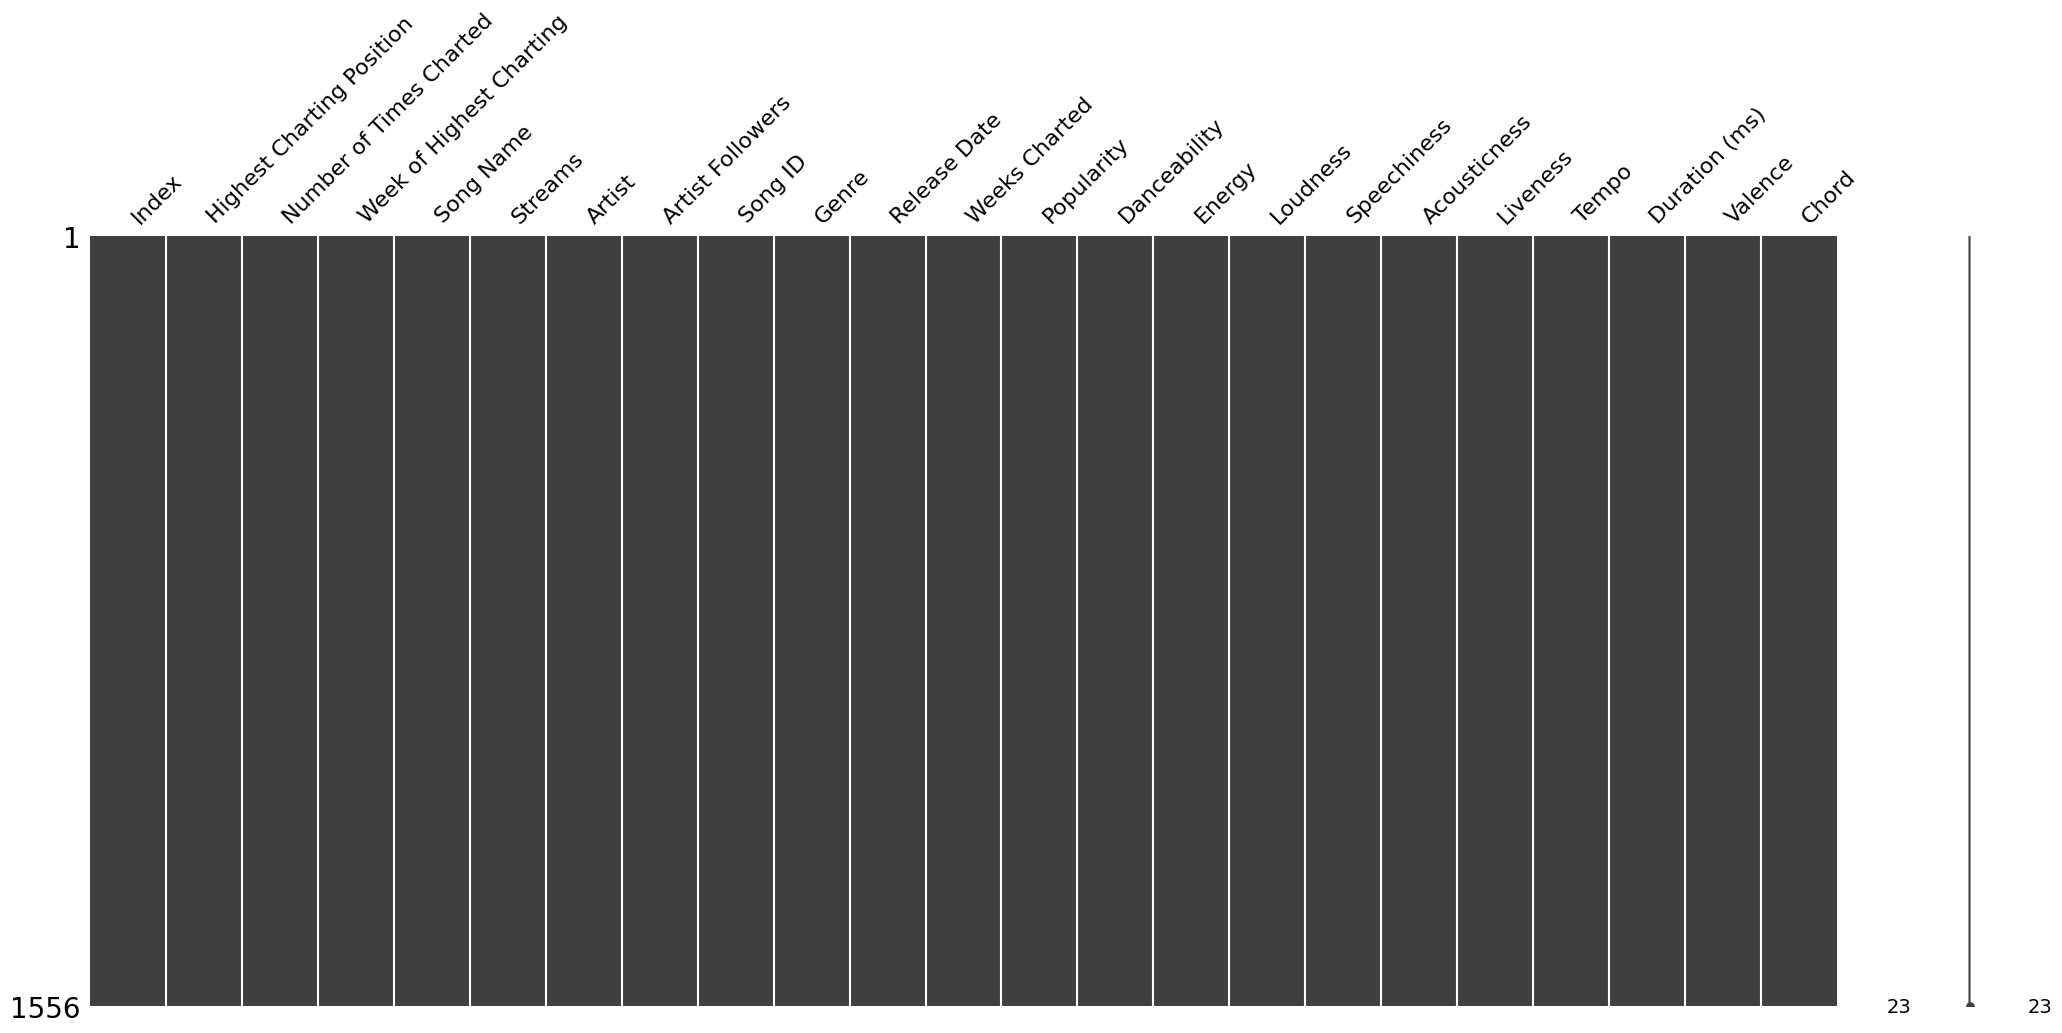

In [8]:
msno.matrix(df)

In [9]:
df.head()

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


In [10]:
df.tail()

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F
1555,1556,199,1,2019-12-27--2020-01-03,Lover (Remix) [feat. Shawn Mendes],"4,595,450",Taylor Swift,42227614,3i9UVldZOE0aD0JnyfAZZ0,"['pop', 'post-teen pop']",...,0.448,0.603,-7.176,0.064,0.433,0.0862,205.272,221307,0.422,G


## Data Type Audit

| Column | Current dtype | Expected dtype | Example Value |
|--------|--------------|----------------|---------------|
| Index | int64 | int64 | `1` |
| Highest Charting Position | str | int64 | `1` |
| Number of Times Charted | int64 | int64 | `8` |
| Week of Highest Charting | str | datetime | `2021-07-23--2021-07-30` |
| Song Name | str | str | `Beggin'` |
| Streams | str | int64 | `48,633,449` |
| Artist | str | str | `Måneskin` |
| Artist Followers | str | int64 | `3377762` |
| Song ID | str | str | `3Wrjm47oTz2sjIgck11l5e` |
| Genre | str | list | `['indie rock italiano', 'italian pop']` |
| Release Date | str | datetime | `2017-12-08` |
| Weeks Charted | str | list | `2021-07-23--2021-07-30\n2021-07-16--...` |
| Popularity | str | int64 | `100` |
| Danceability | str | float64 | `0.714` |
| Energy | str | float64 | `0.8` |
| Loudness | str | float64 | `-4.808` |
| Speechiness | str | float64 | `0.0504` |
| Acousticness | str | float64 | `0.127` |
| Liveness | str | float64 | `0.359` |
| Tempo | str | float64 | `134.002` |
| Duration (ms) | str | int64 | `211560` |
| Valence | str | float64 | `0.589` |
| Chord | str | str | `B` |

## Data Cleaning

In [11]:
cleaned_df = df.copy()

In [12]:
# Drop 'Index' column — row counter with no predictive value
cleaned_df = cleaned_df.drop(columns=['Index'])

In [13]:
# Cast 'Highest Charting Position' from str to Int64, coercing bad values to NaN
cleaned_df['Highest Charting Position'] = pd.to_numeric(
    cleaned_df['Highest Charting Position'], errors='coerce'
).astype('Int64')

In [14]:
# Extract start date from 'Week of Highest Charting' range string and convert to datetime
cleaned_df['Week of Highest Charting'] = pd.to_datetime(
    cleaned_df['Week of Highest Charting'].str.split('--').str[0], errors='coerce'
)

In [15]:
# Strip commas from 'Streams' and cast to Int64, coercing bad values to NaN
cleaned_df['Streams'] = pd.to_numeric(
    cleaned_df['Streams'].str.replace(',', '', regex=False), errors='coerce'
).astype('Int64')

In [16]:
# Strip commas from 'Artist Followers' and cast to Int64, coercing bad values to NaN
cleaned_df['Artist Followers'] = pd.to_numeric(
    cleaned_df['Artist Followers'].str.replace(',', '', regex=False), errors='coerce'
).astype('Int64')

In [17]:
# Drop 'Song ID' column — Spotify identifier with no predictive value
cleaned_df = cleaned_df.drop(columns=['Song ID'])

In [18]:
# Convert 'Release Date' from str to datetime
cleaned_df['Release Date'] = pd.to_datetime(cleaned_df['Release Date'], errors='coerce')

In [19]:
# Parse 'Weeks Charted' into a list of start dates from each weekly range
cleaned_df['Weeks Charted'] = cleaned_df['Weeks Charted'].apply(
    lambda x: [r.split('--')[0] for r in x.split('\n') if '--' in r] if pd.notna(x) else []
)

In [20]:
# Cast 'Popularity' from str to Int64, coercing bad values to NaN
cleaned_df['Popularity'] = pd.to_numeric(cleaned_df['Popularity'], errors='coerce').astype('Int64')

In [21]:
# Cast audio feature columns from str to float64, coercing bad values to NaN
audio_features = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Valence']
cleaned_df[audio_features] = cleaned_df[audio_features].apply(pd.to_numeric, errors='coerce')

In [22]:
# Cast 'Duration (ms)' from str to Int64, coercing bad values to NaN
cleaned_df['Duration (ms)'] = pd.to_numeric(cleaned_df['Duration (ms)'], errors='coerce').astype('Int64')

In [23]:
# Verify all dtypes after cleaning
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Highest Charting Position  1556 non-null   Int64         
 1   Number of Times Charted    1556 non-null   int64         
 2   Week of Highest Charting   1556 non-null   datetime64[ns]
 3   Song Name                  1556 non-null   object        
 4   Streams                    1556 non-null   Int64         
 5   Artist                     1556 non-null   object        
 6   Artist Followers           1545 non-null   Int64         
 7   Genre                      1556 non-null   object        
 8   Release Date               1528 non-null   datetime64[ns]
 9   Weeks Charted              1556 non-null   object        
 10  Popularity                 1545 non-null   Int64         
 11  Danceability               1545 non-null   float64       
 12  Energy

<Axes: >

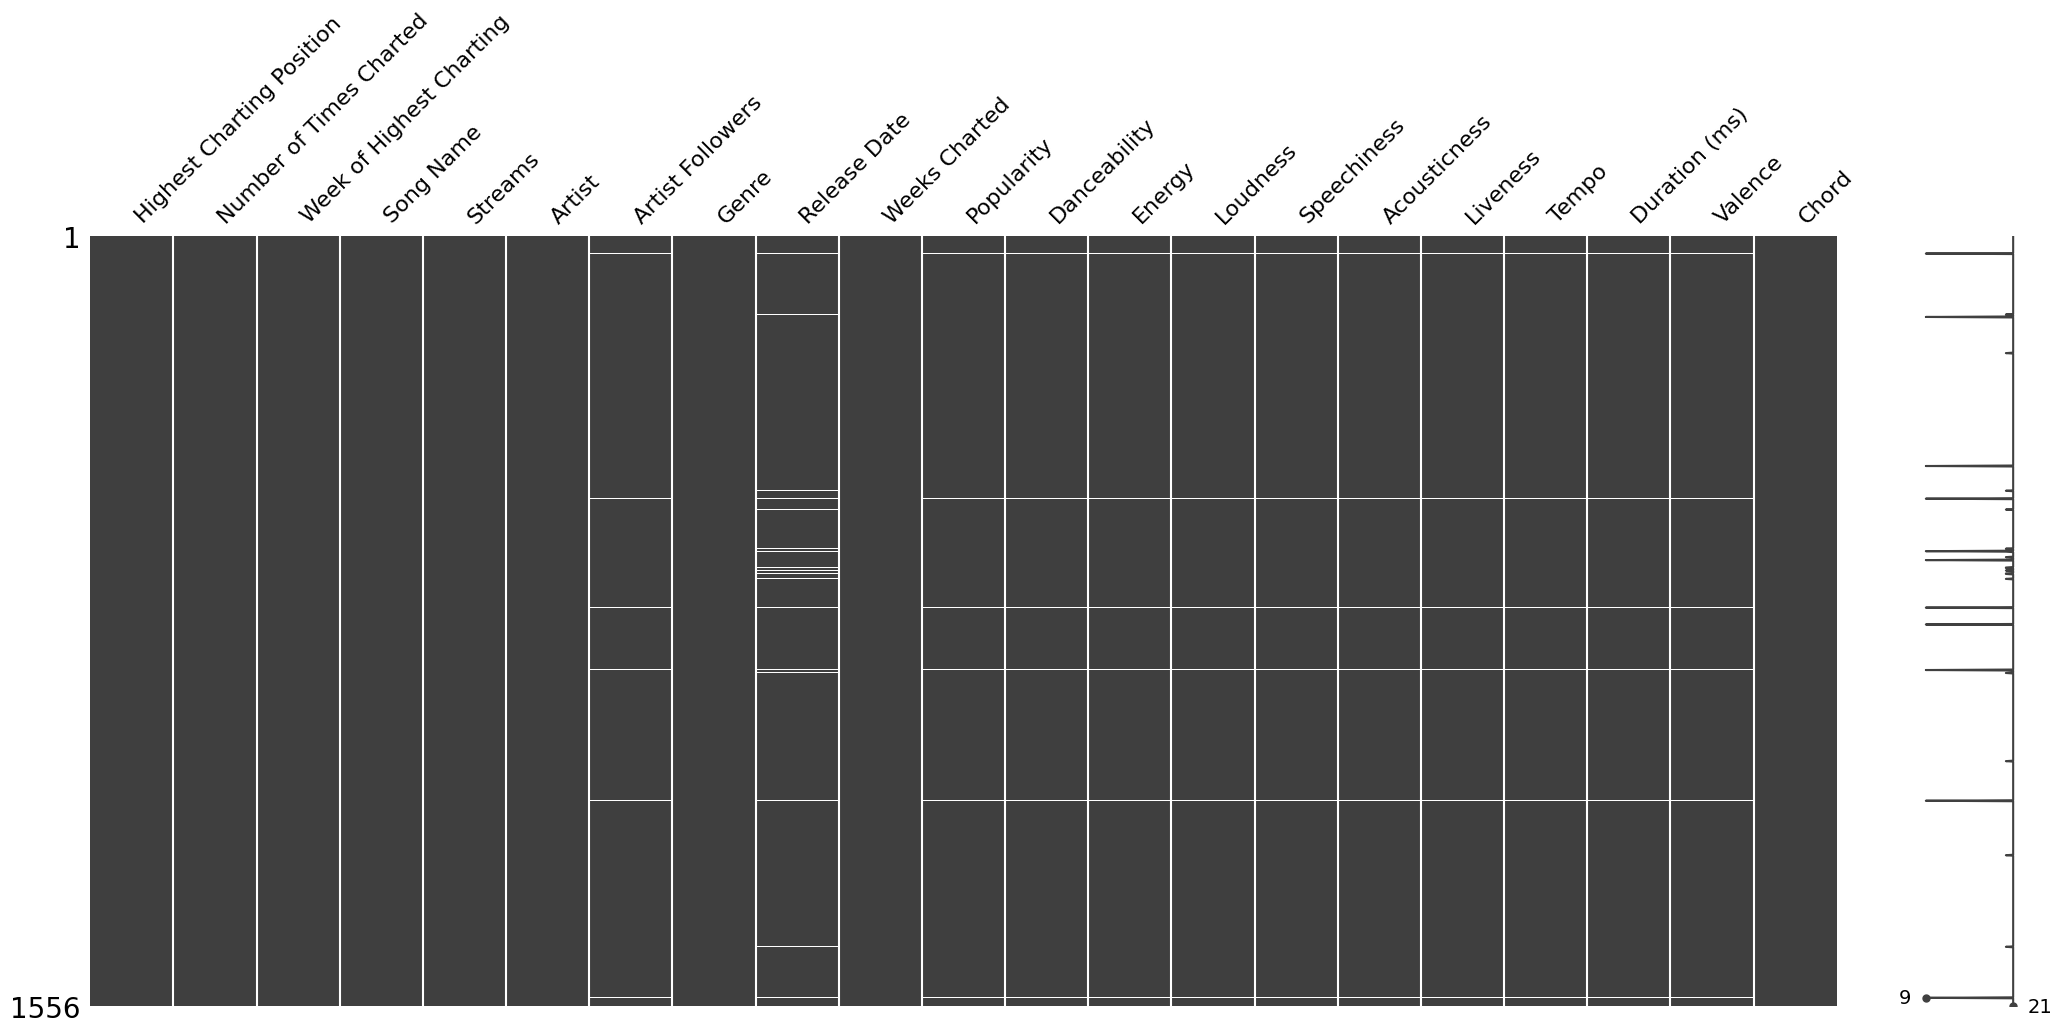

In [24]:
msno.matrix(cleaned_df)

## Data Cleaning Summary

| Column | Change Applied |
|--------|---------------|
| Index | Dropped — row counter with no predictive value |
| Highest Charting Position | `str` → `Int64` via `pd.to_numeric(errors='coerce')` |
| Number of Times Charted | No change — already `int64` |
| Week of Highest Charting | Extracted start date from range string, converted to `datetime` |
| Song Name | No change — already `str` |
| Streams | Stripped commas, cast to `Int64` via `pd.to_numeric(errors='coerce')` |
| Artist | No change — already `str` |
| Artist Followers | Stripped commas, cast to `Int64` via `pd.to_numeric(errors='coerce')` |
| Song ID | Dropped — Spotify identifier with no predictive value |
| Genre | Parsed string-list, one-hot encoded into binary genre columns |
| Release Date | `str` → `datetime` via `pd.to_datetime(errors='coerce')` |
| Weeks Charted | Parsed into list of weekly start dates |
| Popularity | `str` → `Int64` via `pd.to_numeric(errors='coerce')` |
| Danceability | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Energy | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Loudness | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Speechiness | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Acousticness | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Liveness | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Tempo | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Duration (ms) | `str` → `Int64` via `pd.to_numeric(errors='coerce')` |
| Valence | `str` → `float64` via `pd.to_numeric(errors='coerce')` |
| Chord | No change — already `str`, categorical encoding deferred to modeling |

## Imputation

The null check shows that all 11 nulls across the audio features, `Artist Followers`, and `Popularity` belong to the **same 11 rows** — bad values introduced when type casting with `errors='coerce'`. Dropping rows where `Popularity` is null eliminates all of those in one step.

After that, only `Release Date` has remaining nulls (28 rows), which are forward filled.

In [25]:
# Check null counts per column
cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0]

,0
Artist Followers,11
Release Date,28
Popularity,11
Danceability,11
Energy,11
Loudness,11
Speechiness,11
Acousticness,11
Liveness,11
Tempo,11


In [26]:
# Drop rows where Popularity is null — it is the target variable, imputing it would introduce bias
cleaned_df = cleaned_df.dropna(subset=['Popularity'])

<Axes: >

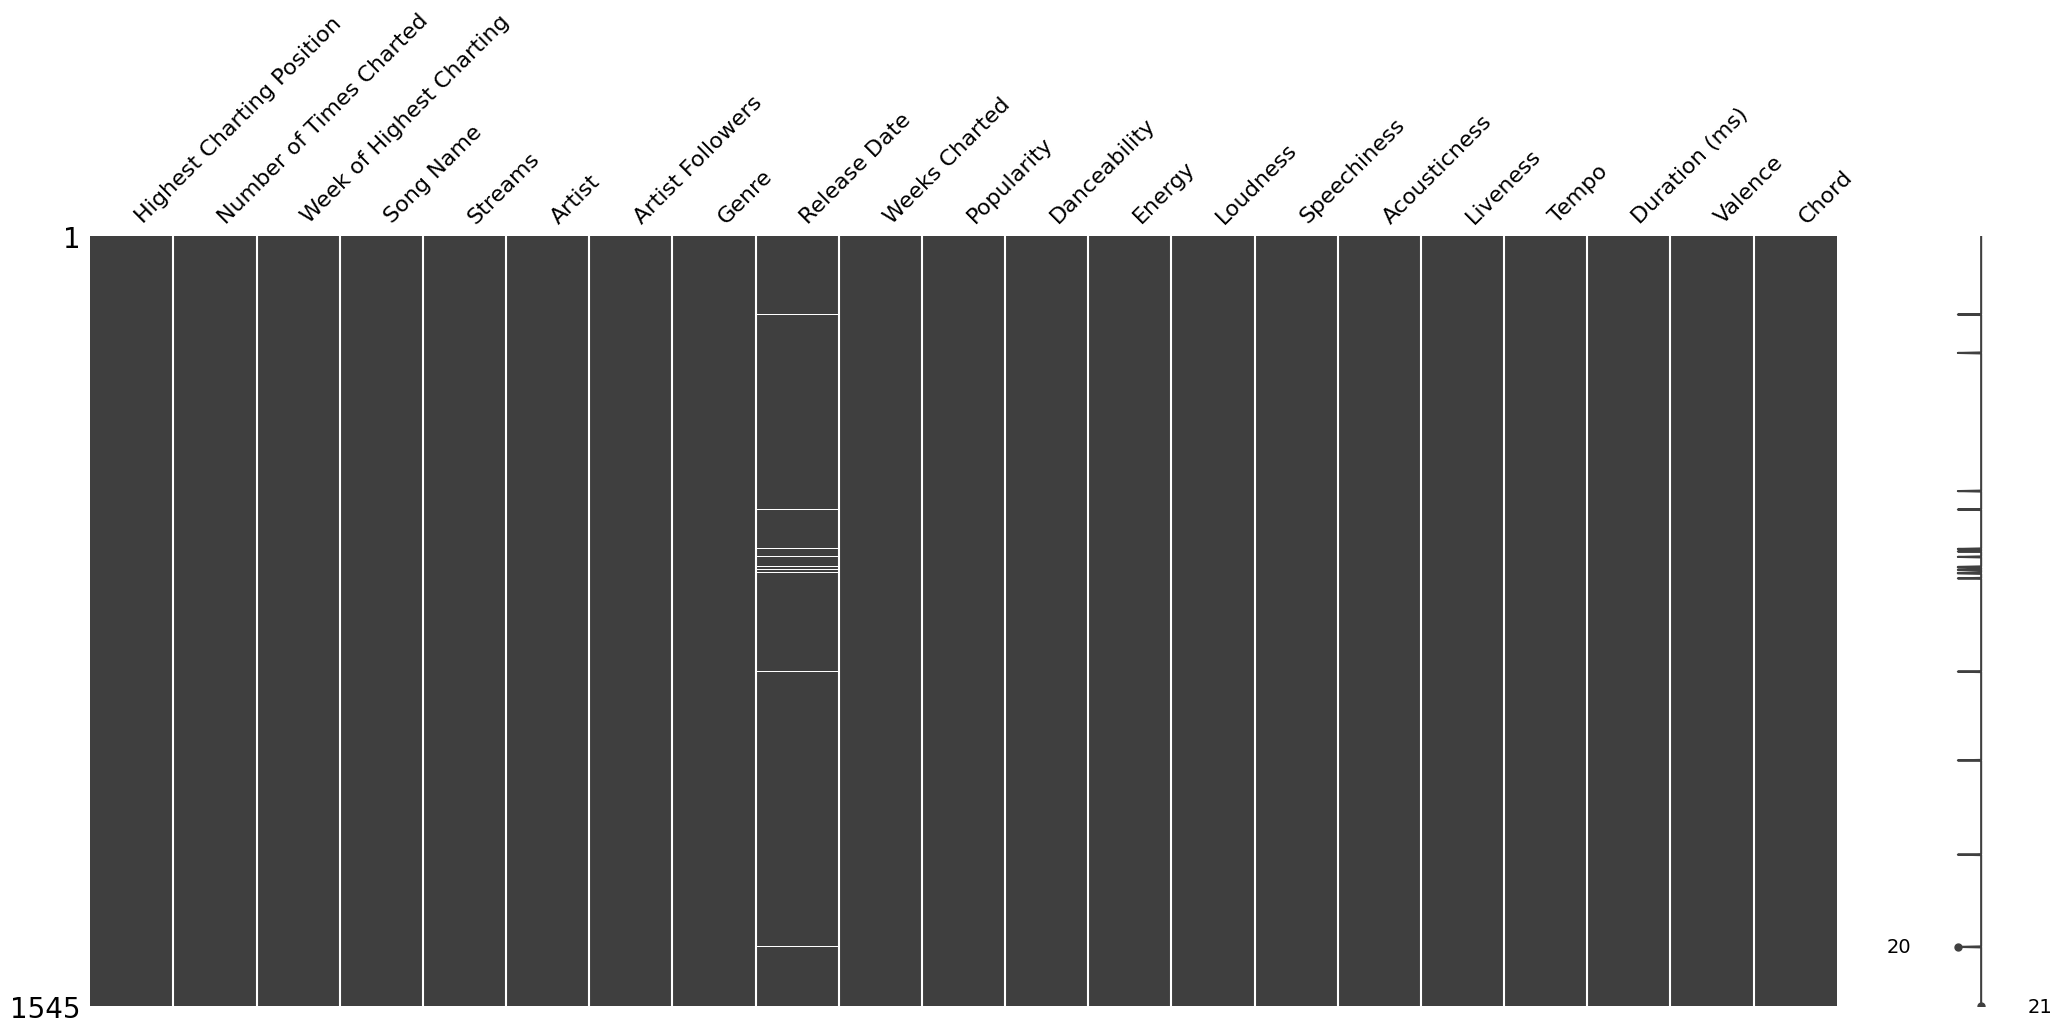

In [27]:
msno.matrix(cleaned_df)

In [28]:
# Null check after dropping Popularity rows — confirms only Release Date nulls remain
cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0]

,0
Release Date,17


In [29]:
# Impute datetime columns with forward fill
datetime_cols = cleaned_df.select_dtypes(include=['datetime']).columns
cleaned_df[datetime_cols] = cleaned_df[datetime_cols].ffill()

In [30]:
# Confirm no nulls remain, excluding Weeks Charted (list column, intentionally left as-is)
cleaned_df.drop(columns=['Weeks Charted']).isnull().sum().sum()

np.int64(0)

In [31]:
cleaned_df.shape

(1545, 21)

<Axes: >

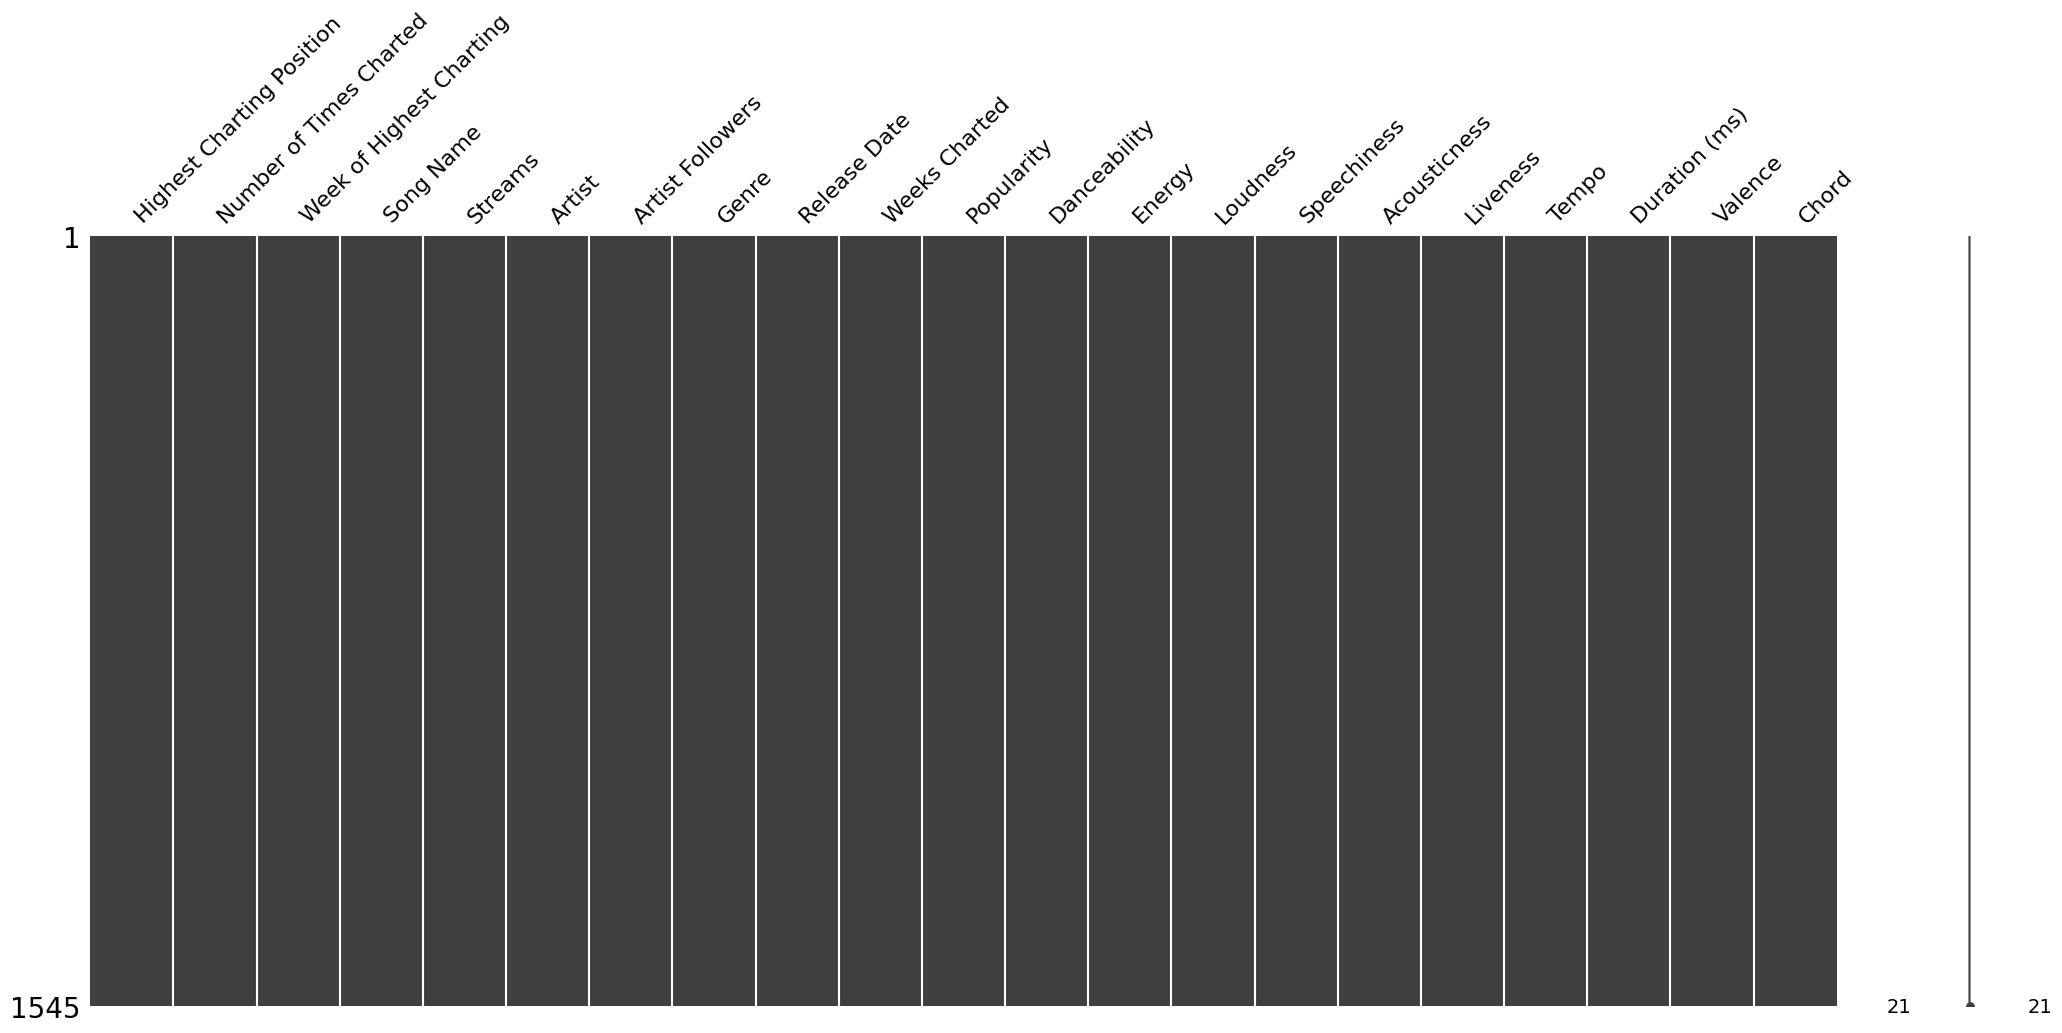

In [32]:
msno.matrix(cleaned_df)

## Imputation Summary

| Column | Strategy | Reason |
|--------|----------|--------|
| Popularity | Drop rows | Target variable — imputing would introduce bias into the model |
| Audio features + Artist Followers | No imputation needed | Same 11 rows as Popularity nulls — eliminated by the Popularity drop |
| Release Date | Forward fill | 28 nulls remaining after Popularity drop; most recent known date is the best proxy |
| All other columns | No imputation needed | No nulls present in raw data |

## EDA

##Picking the right target

## Determining the Target Variable

The dataset has several candidates for the target: `Popularity`, `Streams`, `Highest Charting Position`, and `Number of Times Charted`.

Using `Popularity`

- `Popularity` is Spotify's own continuously-updated 0–100 score that weights both total plays *and* recency — it doesn't unfairly reward songs that have simply existed longer.

In [33]:
px.histogram(cleaned_df['Popularity'])

In [34]:
# Correlation between Popularity and the alternative target candidates
# Shows they are related but measure different things
corr_cols = ['Popularity', 'Streams', 'Number of Times Charted', 'Highest Charting Position', 'Artist Followers']
corr_df = cleaned_df[corr_cols].apply(pd.to_numeric, errors='coerce').corr()

fig = px.imshow(
    corr_df,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Correlation: Popularity vs Alternative Targets & Artist Followers',
)
fig.show()

## Choosing Appropriate Predictors

The key question for every column: **"Would we know this before the song is released?"**

| Column | Keep? | Reason |
|--------|-------|--------|
| Danceability, Energy, Loudness, Speechiness, Acousticness, Liveness, Tempo, Valence | ✅ | Audio features known at production time |
| Duration (ms) | ✅ | Known before release |
| Chord | ✅ | Known before release |
| Release Date → Year, Month | ✅ (engineered) | Planned release date is known |
| Artist Followers | ✅ | Measurable before release |
| Genre | ✅ (needs encoding) | Assigned at production time |
| **Streams** | ❌ Drop | Post-release metric — direct leakage |
| **Number of Times Charted** | ❌ Drop | Post-release metric |
| **Highest Charting Position** | ❌ Drop | Post-release metric |
| **Week of Highest Charting** | ❌ Drop | Post-release metric |
| **Weeks Charted** | ❌ Drop | Post-release metric |
| Song Name | ❌ Drop | Free-text with no predictive signal |
| Artist | ❌ Drop | High-cardinality text; Followers captures artist reach instead |

In [35]:
# Drop all crystal-ball columns — these cannot be known before a song is released
crystal_ball_cols = [
    'Streams', 'Number of Times Charted', 'Highest Charting Position',
    'Week of Highest Charting', 'Weeks Charted', 'Song Name', 'Artist'
]

model_df = cleaned_df.drop(columns=crystal_ball_cols)
print(f"Remaining columns ({model_df.shape[1]}):")
print(model_df.columns.tolist())

Remaining columns (14):
['Artist Followers', 'Genre', 'Release Date', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Chord']


## Feature Engineering

1. **Release Year & Release Month** — extract from `Release Date`; captures recency trend + seasonal patterns (summer hits, holiday releases)
2. **Genre count** — how many genres a song spans (broader = more mainstream reach)
3. **Genre broad category flags** — parse the string-list `Genre` column into 10 broad regex-matched binary features
4. **Artist experience** — count of how many songs by that artist appear earlier in the dataset, sorted by release date (proxy for established vs. debut artist)

In [36]:
# 1. Extract Release Year and Release Month from Release Date
model_df['Release Year'] = model_df['Release Date'].dt.year.astype(int)
model_df['Release Month'] = model_df['Release Date'].dt.month.astype(int)
model_df = model_df.drop(columns=['Release Date'])


In [37]:
import re

def parse_genre(x):
    return re.findall(r"'([^']*)'", str(x))

genre_lists = model_df['Genre'].apply(parse_genre)
model_df['Genre Count'] = genre_lists.apply(len)

# re.compile(pattern, flags) — compiles the pattern once into a reusable regex object
#   Compiling up front is faster than recompiling on every row
# re.IGNORECASE — makes the match case-insensitive (Pop == pop == POP)
# \b           — word boundary: zero-width assertion between a word char (\w) and a non-word char
#                prevents partial matches (e.g. \bpop\b matches "pop" but not "tropical")
# (a|b|c)      — alternation: matches any one of the pipe-separated alternatives
# .?           — any single character, zero or one time
#                lets hip.?hop match both "hip hop" (space) and "hip-hop" (hyphen)
# re.search(g) — scans through string g and returns the first match anywhere in it
#                (unlike re.match which only checks the start of the string)
broad_map = {
    'is_pop':        re.compile(r'\bpop\b', re.IGNORECASE),
    'is_hip_hop':    re.compile(r'\b(hip.?hop|rap|drill)\b', re.IGNORECASE),
    'is_rock':       re.compile(r'\b(rock|punk|metal|grunge|alternative)\b', re.IGNORECASE),
    'is_latin':      re.compile(r'\b(latin|reggaeton|trap latino|salsa|bachata|mariachi|ranchera|regional mexican|sertanejo|urbano)\b', re.IGNORECASE),
    'is_rb':         re.compile(r'\b(r&b|soul|neo.?soul|funk)\b', re.IGNORECASE),
    'is_electronic': re.compile(r'\b(edm|house|techno|electronic|electro|synth)\b', re.IGNORECASE),
    'is_dance':      re.compile(r'\bdance\b', re.IGNORECASE),
    'is_indie':      re.compile(r'\bindie\b', re.IGNORECASE),
    'is_country':    re.compile(r'\b(country|bluegrass|americana)\b', re.IGNORECASE),
    'is_acoustic':   re.compile(r'\b(folk|acoustic|singer.?songwriter)\b', re.IGNORECASE),
}

for col, pattern in broad_map.items():
    model_df[col] = genre_lists.apply(
        lambda genres: int(any(pattern.search(g) for g in genres))
    )

model_df = model_df.drop(columns=['Genre'])

flag_cols = list(broad_map.keys())
covered = model_df[flag_cols].any(axis=1).sum()
print(f"Songs covered by at least one genre bucket: {covered} / {len(model_df)} ({covered/len(model_df):.1%})")
print(model_df[flag_cols].sum().sort_values(ascending=False))


Songs covered by at least one genre bucket: 1431 / 1545 (92.6%)
is_pop           817
is_hip_hop       615
is_dance         275
is_latin         223
is_rb            101
is_rock           94
is_electronic     76
is_indie          36
is_country        14
is_acoustic       11
dtype: int64


In [38]:
raw_genre = cleaned_df.loc[model_df.index, 'Genre']

# Rows where parse_genre returned an empty list (failed to extract anything)
empty_parsed = raw_genre[genre_lists.apply(len) == 0]
print(f"Rows with empty parse result: {len(empty_parsed)}")
print(empty_parsed.values[:10])

# Rows with double quotes instead of single quotes
double_quoted = raw_genre[raw_genre.str.contains('"', na=False)]
print(f"\nRows using double quotes: {len(double_quoted)}")
print(double_quoted.values[:5])

# Genres with apostrophes that would break the single-quote parser
apostrophe_genres = raw_genre[raw_genre.str.contains(r"'\w", na=False) & ~raw_genre.str.startswith("['")]
print(f"\nPotential apostrophe issues: {len(apostrophe_genres)}")
print(apostrophe_genres.values[:5])

# What genres do the uncovered songs actually have?
flag_cols = [c for c in model_df.columns if c.startswith('is_')]
uncovered_idx = model_df[model_df[flag_cols].sum(axis=1) == 0].index
print(f"\nSample uncovered genres:")
print(raw_genre.loc[uncovered_idx].value_counts().head(15))

Rows with empty parse result: 75
['[]' '[]' '[]' '[]' '[]' '[]' '[]' '[]' '[]' '[]']

Rows using double quotes: 0
[]

Potential apostrophe issues: 0
[]

Sample uncovered genres:
Genre
[]                                                                        75
['australian psych', 'neo-psychedelic']                                    5
['adult standards', 'easy listening', 'lounge', 'vocal jazz']              4
['adult standards', 'easy listening', 'lounge']                            3
['forro', 'piseiro']                                                       3
['comic']                                                                  2
['forro']                                                                  2
['piseiro']                                                                2
['basshall', 'francoton']                                                  2
['adult standards', 'easy listening', 'lounge', 'swing', 'vocal jazz']     2
['dream smp']                                 

In [39]:
# 4. Artist experience — count of prior songs by same artist in dataset (sorted by release date)
# Re-attach Artist temporarily from cleaned_df for the calculation
model_df['Artist'] = cleaned_df.loc[model_df.index, 'Artist']
model_df = model_df.sort_values(['Artist', 'Release Year', 'Release Month'])
model_df['Artist Experience'] = model_df.groupby('Artist').cumcount()
model_df = model_df.drop(columns=['Artist'])
model_df = model_df.sort_index()

In [40]:
model_df = pd.get_dummies(model_df, columns=['Chord'], drop_first=True)

print(f"Final model_df: {model_df.shape[0]} rows × {model_df.shape[1]} columns")
print(f"Null values remaining: {model_df.drop(columns='Popularity').isnull().sum().sum()}")
model_df.head(3)

Final model_df: 1545 rows × 36 columns
Null values remaining: 0


,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),...,Chord_B,Chord_C,Chord_C#/Db,Chord_D,Chord_D#/Eb,Chord_E,Chord_F,Chord_F#/Gb,Chord_G,Chord_G#/Ab
0,3377762,100,0.714,0.800,-4.808,0.0504,0.1270,0.3590,134.002,211560,...,True,False,False,False,False,False,False,False,False,False
1,2230022,99,0.591,0.764,-5.484,0.0483,0.0383,0.1030,169.928,141806,...,False,False,True,False,False,False,False,False,False,False
2,6266514,99,0.563,0.664,-5.044,0.1540,0.3350,0.0849,166.928,178147,...,False,False,False,False,False,False,False,False,False,False


## Model

In [41]:
# Define features and target
X = model_df.drop(columns=['Popularity'])
y = model_df['Popularity']

In [42]:
# # Train/test split — 80/20, stratification not needed for regression
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print(f"Train: {X_train.shape}, Test: {X_test.shape}")

In [43]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Artist Followers   1545 non-null   Int64  
 1   Popularity         1545 non-null   Int64  
 2   Danceability       1545 non-null   float64
 3   Energy             1545 non-null   float64
 4   Loudness           1545 non-null   float64
 5   Speechiness        1545 non-null   float64
 6   Acousticness       1545 non-null   float64
 7   Liveness           1545 non-null   float64
 8   Tempo              1545 non-null   float64
 9   Duration (ms)      1545 non-null   Int64  
 10  Valence            1545 non-null   float64
 11  Release Year       1545 non-null   int64  
 12  Release Month      1545 non-null   int64  
 13  Genre Count        1545 non-null   int64  
 14  is_pop             1545 non-null   int64  
 15  is_hip_hop         1545 non-null   int64  
 16  is_rock            1545 non-n

In [44]:

numLoops = 500

mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=5, random_state=0)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()}')
print(f'RMSE_std: {np.sqrt(mean_error).std()}')

RMSE: 9.331358570157278
RMSE_std: 0.6965989999318062


In [45]:
import plotly.express as px

rmse_vals = np.sqrt(mean_error)

fig = px.histogram(
    x=rmse_vals,
    nbins=30,
    title='Decision Tree RMSE Distribution (500 splits)',
    labels={'x': 'RMSE'},
)
fig.add_vline(
    x=rmse_vals.mean(), line_dash='dash', line_color='red',
    annotation_text=f'Mean: {rmse_vals.mean():.2f}',
)
fig.add_vline(
    x=rmse_vals.mean() - rmse_vals.std(), line_dash='dot', line_color='grey',
    annotation_text=f'-1 std: {rmse_vals.mean() - rmse_vals.std():.2f}',
)
fig.add_vline(
    x=rmse_vals.mean() + rmse_vals.std(), line_dash='dot', line_color='grey',
    annotation_text=f'+1 std: {rmse_vals.mean() + rmse_vals.std():.2f}',
)
fig.show()

In [55]:
# Specify the parameters you want to try and their ranges.
param_test = {
 'max_depth'     : [  7,  ],
 'learning_rate' : [ 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:squarederror', seed = 10 ),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

# Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42 )
model = gsearch.fit(X_train,y_train)

# See grid search results
print(model.best_params_)


{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 60}


In [53]:
params = model.best_params_

numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.15 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      # learning_rate = 0.2,
      # max_depth = 3,
      # n_estimators = 100,
      seed = 10,
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 8.255268659481123


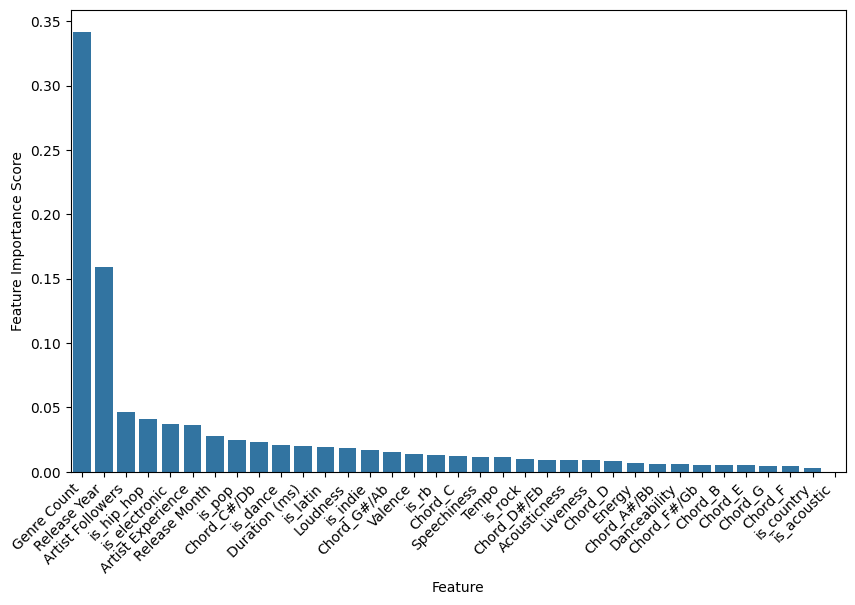

In [54]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values( ascending = False )
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values )
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score') ;

In [49]:
(feat_imp.sort_values( ascending = False )*100).cumsum()

,0
Genre Count,34.522022
Release Year,44.995220
Artist Followers,51.948471
Artist Experience,55.652485
is_rock,59.155697
is_hip_hop,62.583324
is_pop,65.353645
Release Month,67.993675
Chord_C#/Db,70.524910
Chord_G#/Ab,72.558044


In [50]:
# Predicted vs Actual — from the last loop iteration
fig = px.scatter(
    x=y_test, y=y_pred_xgb,
    opacity=0.5,
    labels={'x': 'Actual Popularity', 'y': 'Predicted Popularity'},
    title='Predicted vs Actual Popularity',
)
fig.add_shape(
    type='line',
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color='red', dash='dash'),
)
fig.show()


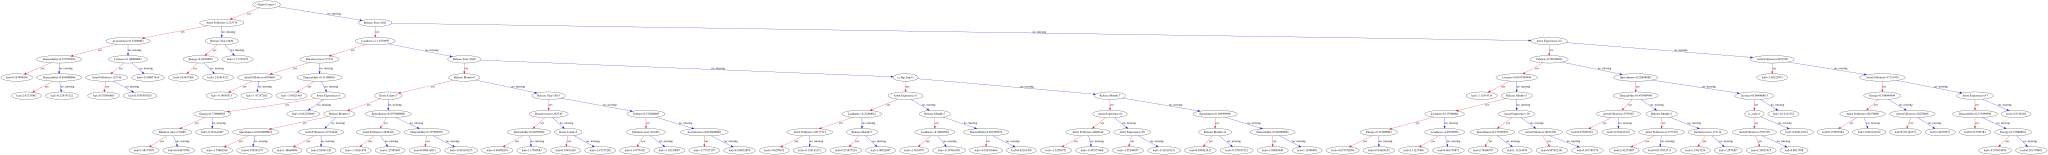

In [64]:
xgb.to_graphviz(xgbr)


## Conclusion
- XGBoost (RMSE: 8.11)
- Genre Count and Release Year drove 50% of the model's decisions, confirming that  crossover appeal and recency are strong predictors of Spotify popularity
- Post-release leakage (streams, chart positions) was explicitly excluded, meaning predictions reflect what is knowable before a song drops

Next Steps:
- Expand the dataset
- Engineer stronger artist features: log-transform target
- Drop low-signal features (chord dummies, is_acoustic) and test whether a cleaner feature set improves RMSE
